In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [12]:
NationalAverage = pd.read_csv('NationalAverage.csv')
ProviderSpecialty = pd.read_csv('ProviderSpecialty.csv')
StateSummary = pd.read_csv('StateSummary.csv')
Top5EachState = pd.read_csv('Top5EachState.csv')

In [13]:
print(NationalAverage.head())
print(ProviderSpecialty.head())
print(StateSummary.head())
print(Top5EachState.head())

   Provider_NPI                             Provider_LastName  \
0    1386004018                     Coppel Surgical Solutions   
1    1447661145  Advanced Outpatient Surgery Of Oklahoma, Llc   
2    1760859334        Visalia Ambulatory Surgical Center Llc   
3    1922625995       National Surgical Centers Stockton, Llc   
4    1982246575      Golden State Heart & Vascular Associates   

          Provider_Speciality State  Provider_Avg  National_Avg  Difference  
0  Ambulatory Surgical Center    NV  21166.730000   1301.589122    19865.14  
1  Ambulatory Surgical Center    OK  14795.130000   1301.589122    13493.54  
2  Ambulatory Surgical Center    CA  14449.973333   1301.589122    13148.38  
3  Ambulatory Surgical Center    CA  13392.762500   1301.589122    12091.17  
4  Ambulatory Surgical Center    CA  12978.210000   1301.589122    11676.62  
          Provider_Speciality  Total_Providers  Avg_Payment  Total_Payment
0  Ambulatory Surgical Center             5411      1301.59    793

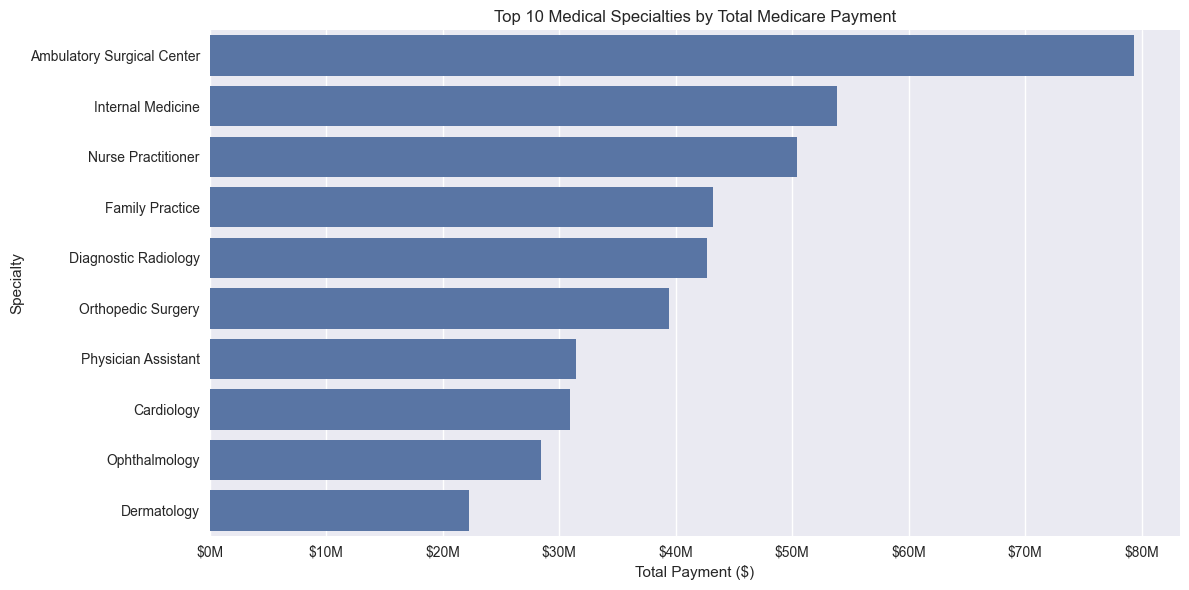

In [19]:

Top10_specialties = ProviderSpecialty.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data= Top10_specialties, x='Total_Payment', y='Provider_Speciality')
plt.title('Top 10 Medical Specialties by Total Medicare Payment')
plt.xlabel('Total Payment ($)')
plt.ylabel('Specialty')

# Fix x axis to show readable numbers
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1_000_000:.0f}M')
)

plt.tight_layout()
plt.savefig('top10_specialties.png')
plt.show()

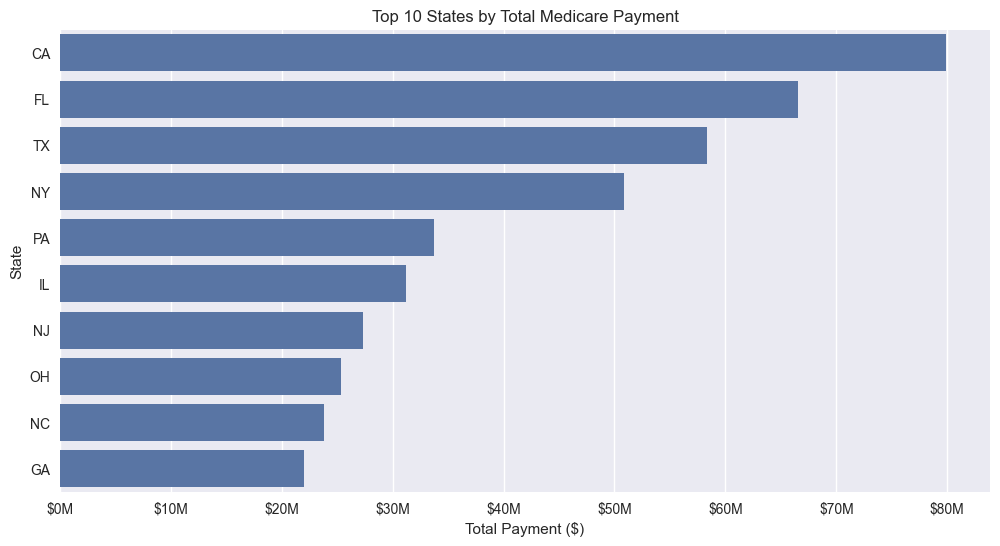

In [22]:
Top10ByState = StateSummary.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=Top10ByState, x='Total_Payment', y='State')
plt.title('Top 10 States by Total Medicare Payment')
plt.xlabel('Total Payment ($)')
plt.ylabel('State')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1_000_000:.0f}M')
)
plt.savefig('top10_states.png')
plt.show()

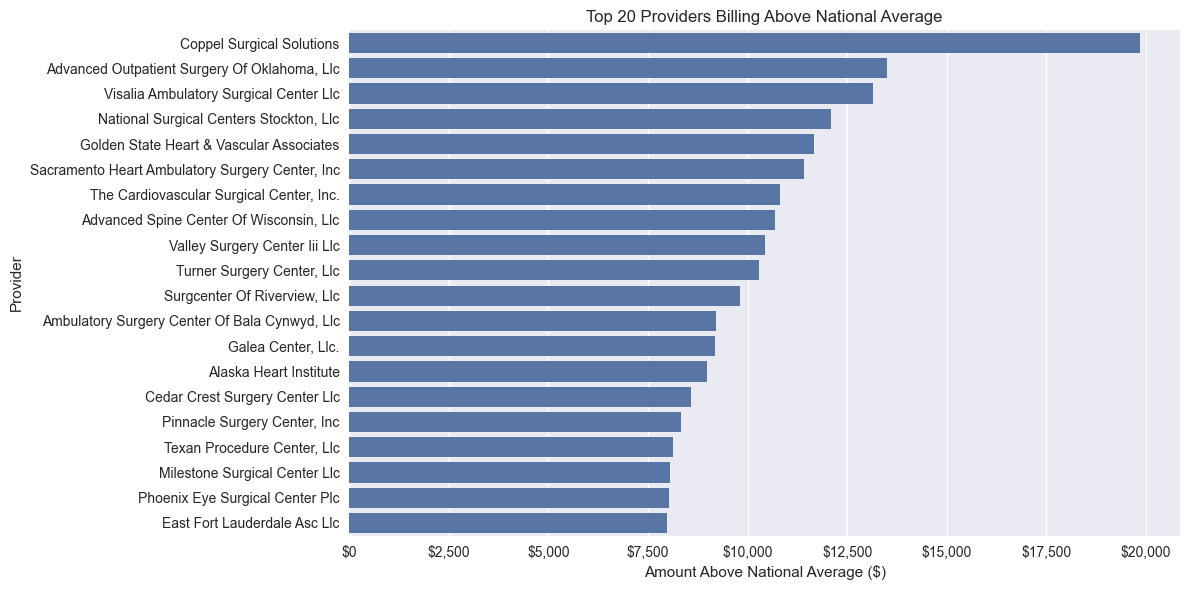

In [24]:
BillingOutlier = NationalAverage

plt.figure(figsize=(12, 6))
sns.barplot(data=BillingOutlier, x='Difference', y='Provider_LastName')
plt.title('Top 20 Providers Billing Above National Average')
plt.xlabel('Amount Above National Average ($)')
plt.ylabel('Provider')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig('billing_outliers.png')
plt.show()

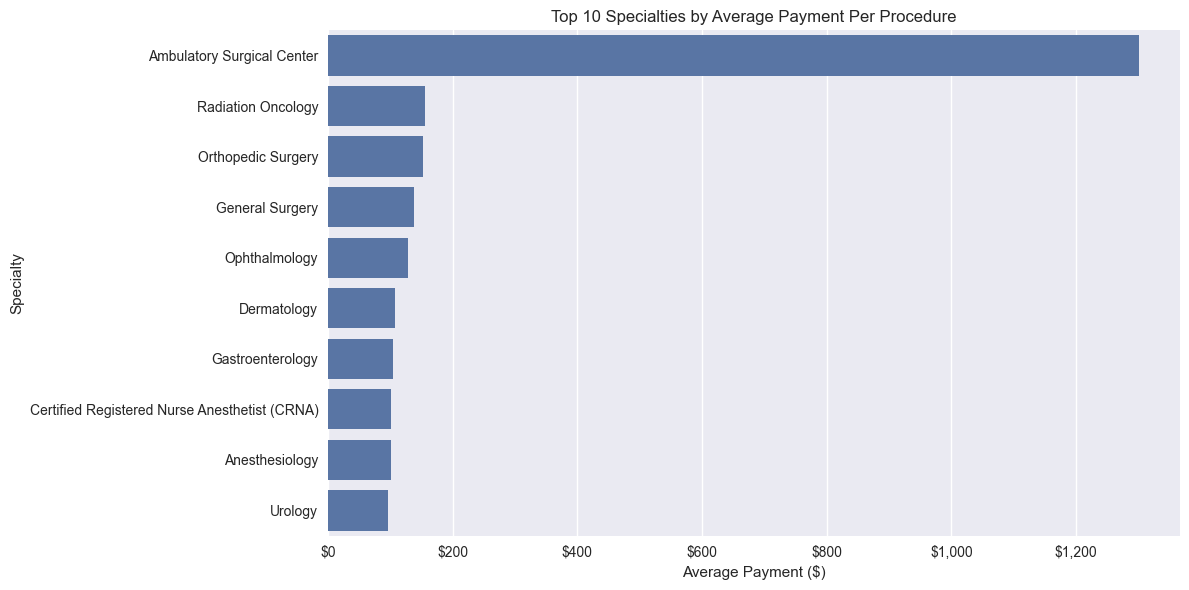

In [27]:
Top10AvgPayment = ProviderSpecialty.sort_values(
    by='Avg_Payment', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=Top10AvgPayment, x='Avg_Payment', y='Provider_Speciality')
plt.title('Top 10 Specialties by Average Payment Per Procedure')
plt.xlabel('Average Payment ($)')
plt.ylabel('Specialty')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig('avg_payment_specialty.png')
plt.show()
